Kernel density estimation
Irreducible mass

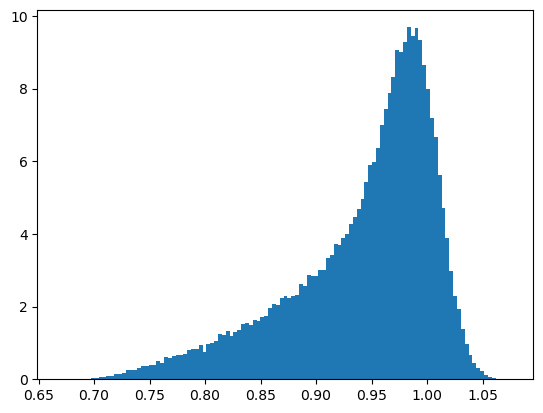

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization.hist import hist

mean = 1
std = 0.02


chi = np.random.uniform(0, 1, 100000)

M = np.random.normal(mean, std, 100000)

M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)

x = np.linspace(min(M_irr), max(M_irr))

hist(M_irr, bins="freedman", density=True);

In [24]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)

    return np.exp(log_pdf)

KDE = kde_sklearn(M_irr,bandwidth=0.1,kernel="linear") 

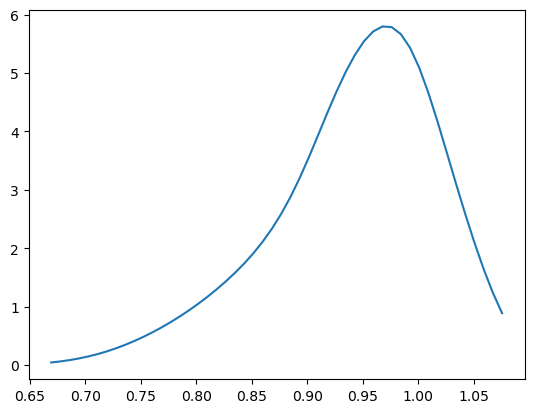

In [25]:
plt.plot(x, KDE) 

In [26]:
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import uniform
import scipy.stats
from scipy import optimize
from astroML import stats as astroMLstats

f = np.sqrt((1+np.sqrt(1-chi**2))/2)
print(stats.ks_2samp(M_irr, f))                 #mean = 1

KstestResult(statistic=0.15810999999999997, pvalue=0.0, statistic_location=0.9999999999975395, statistic_sign=-1)


In [27]:
#do it for many sigmas

sigmas = np.linspace(0, 0.5, 100)
ks_Mirr_f = []
ks_Mirr_M = []

for i in sigmas:
    M = np.random.normal(mean, i, 100000)
    M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)
    f = M_irr/M
    
    ks_Mirr_f.append(scipy.stats.kstest(M_irr, f))
    ks_Mirr_M.append(scipy.stats.kstest(M_irr, M))

In [28]:
print(ks_Mirr_f[1])
ks_Mirr_f = np.array(ks_Mirr_f)
ks_Mirr_M = np.array(ks_Mirr_M)
print(ks_Mirr_f)

KstestResult(statistic=0.08206000000000002, pvalue=2.4672509490257094e-293, statistic_location=0.9999999999975395, statistic_sign=-1)
[[0.00000000e+000 1.00000000e+000]
 [8.20600000e-002 2.46725095e-293]
 [1.14120000e-001 0.00000000e+000]
 [1.40840000e-001 0.00000000e+000]
 [1.60730000e-001 0.00000000e+000]
 [1.78120000e-001 0.00000000e+000]
 [1.94520000e-001 0.00000000e+000]
 [2.04990000e-001 0.00000000e+000]
 [2.18080000e-001 0.00000000e+000]
 [2.28490000e-001 0.00000000e+000]
 [2.39780000e-001 0.00000000e+000]
 [2.48750000e-001 0.00000000e+000]
 [2.58840000e-001 0.00000000e+000]
 [2.64620000e-001 0.00000000e+000]
 [2.72460000e-001 0.00000000e+000]
 [2.79750000e-001 0.00000000e+000]
 [2.87370000e-001 0.00000000e+000]
 [2.98070000e-001 0.00000000e+000]
 [3.02490000e-001 0.00000000e+000]
 [3.07150000e-001 0.00000000e+000]
 [3.12430000e-001 0.00000000e+000]
 [3.16510000e-001 0.00000000e+000]
 [3.24280000e-001 0.00000000e+000]
 [3.26330000e-001 0.00000000e+000]
 [3.31820000e-001 0.000000

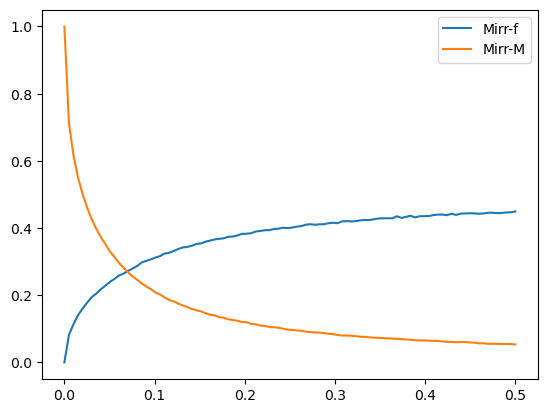

In [29]:
plt.plot(sigmas, ks_Mirr_f[:,0], label="Mirr-f")
plt.plot(sigmas, ks_Mirr_M[:,0], label="Mirr-M")
plt.legend()

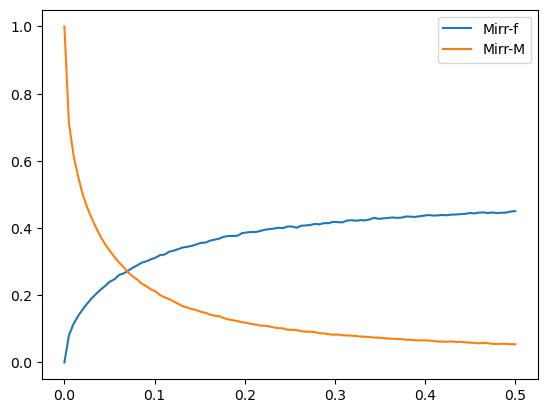

In [30]:
#check what happens if you use ks_2samp

sigmas = np.linspace(0, 0.5, 100)
ks_Mirr_f = []
ks_Mirr_M = []

for i in sigmas:
    M = np.random.normal(mean, i, 100000)
    M_irr = M*np.sqrt((1+np.sqrt(1-chi**2))/2)
    f = M_irr/M
    
    ks_Mirr_f.append(scipy.stats.ks_2samp(M_irr, f))
    ks_Mirr_M.append(scipy.stats.ks_2samp(M_irr, M))

ks_Mirr_f = np.array(ks_Mirr_f)
ks_Mirr_M = np.array(ks_Mirr_M)

plt.plot(sigmas, ks_Mirr_f[:,0], label="Mirr-f")
plt.plot(sigmas, ks_Mirr_M[:,0], label="Mirr-M")
plt.legend()

mi sono accorto che non ho fatto sigma >> mu, ma vedo che il plateau è raggiunto